In [1]:
import os
import sys
import time
import json
import random
import argparse
from pathlib import Path

import torch

# Repo setup
repo_root = "/scratch/jq2uw/MME/instruct_vlm_edit"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)

from argparse import Namespace
from pathlib import Path
import torch 

from revlm.config_utils import configure_args
from revlm.run.edit import run_edit

editor_name = "ike_chain"
# === Change this to test different samples ===
example_idx = 0


In [2]:
# Project root
project_root = Path("/scratch/jq2uw/MME/instruct_vlm_edit")

# Build test paths from args (no hardcoding)
args = Namespace(
    config="revlm/config/config.yaml",
    editor=editor_name,
    model_name="qwen3",
    dataset_name="aokvqa",
    task="mc",
    batch_size=1,
    split="all",
    rationale=False,
    cot=False,
    subsample=10,  # small for testing
    overwrite=True,
)

args.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
config = configure_args(args, config_path=args.config)
config.subsample = args.subsample
config.editor.pair_rationale_w = "both"

config.editor.plot_codebook_pct_threshold = 75
# config.editor.aug_as_keys = False

Task evaluation metrics will be saved to results/te/ike_chain/Qwen3-VL-8B-Instruct/aokvqa
Edit evaluation metrics will be saved to results/ee/ike_chain/Qwen3-VL-8B-Instruct/aokvqa
Predictions will be saved to results/pred/Qwen3-VL-8B-Instruct/aokvqa
Post-edit predictions will be saved to results/pred_postedit/ike_chain/Qwen3-VL-8B-Instruct/aokvqa
Unified filename to save: mc_all_sub10.json


## Step 2: Load Model & Editor


In [3]:
from revlm.models import VQAModel
from revlm.editors import IKE_CHAIN
from revlm.dataset.datasets import VQADataset

# Load model
vlm = VQAModel(config)
print(f"Model loaded: {type(vlm.model).__name__}")

# Load editor
editor = IKE_CHAIN(config, vlm)


# Load dataset
edit_ds = VQADataset(config)
edit_ds.set_dataloader()

# Ensure specific UIDs are included
required_uids = {'9780'}  # Add UIDs you want to include here
required_samples = [ex for ex in edit_ds.data if ex.get("uid") in required_uids]
other_samples = [ex for ex in edit_ds.data if ex.get("uid") not in required_uids]

if config.subsample and len(edit_ds) > config.subsample:
    n_others = max(0, config.subsample - len(required_samples))
    edit_ds.data = required_samples + random.sample(other_samples, min(n_others, len(other_samples)))
print(f"Dataset: {len(edit_ds.data)} samples (required UIDs: {[ex.get('uid') for ex in required_samples]})")


Model loaded: Qwen3VLForConditionalGeneration
Dataset: 10 samples (required UIDs: ['9780'])


## Step 3-4: Visualize Augmentation and Patchification


Question: What material is used to make the stick on the woman's shoulder?
Answer: bamboo
COT: The image shows a woman with a stick on her shoulder. The stick appears firm but flexible. Bamboo is a type of wood that is firm and flexible. Bamboo grows commonly in Asian regions....

s1: The image shows a woman with a stick on her shoulder.
[Augmenter] Loading Qwen/Qwen2.5-1.5B-Instruct...


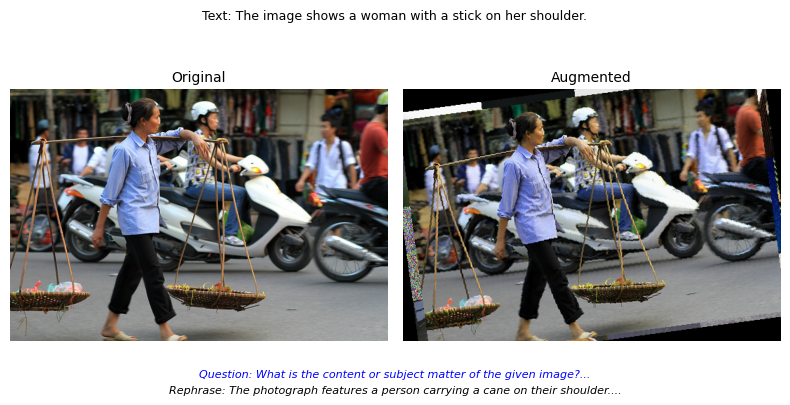

[VQA] Q: Does the image show the image shows a woman with a stick on her shoulder?
[Passed p_yes>0.5]: 6 patches
[Route1 - Smallest unit (1) → best NLL]: ['1x1_1']
[Route2 - Best NLL]: ['2x1_1']
[Selected]: 2 patches


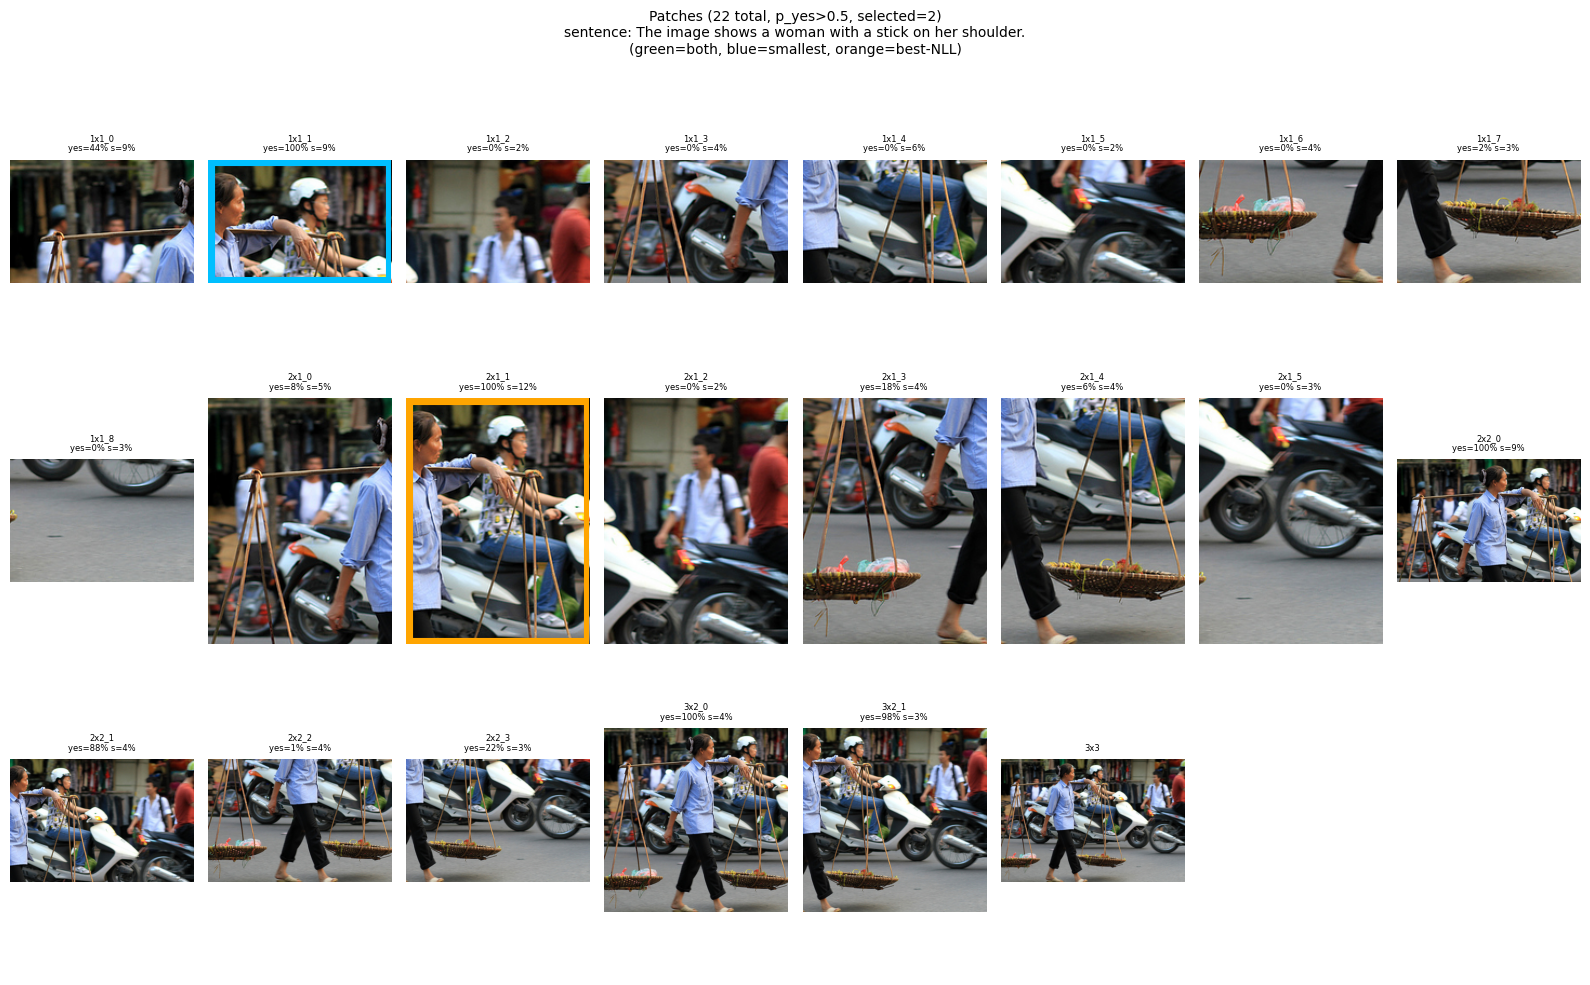

[VQA] Q: Does the image show the stick appears firm but flexible?
[Passed p_yes>0.5]: 16 patches
[Route1 - Smallest unit (1) → best NLL]: ['1x1_4']
[Route2 - Best NLL]: ['2x1_1']
[Selected]: 2 patches


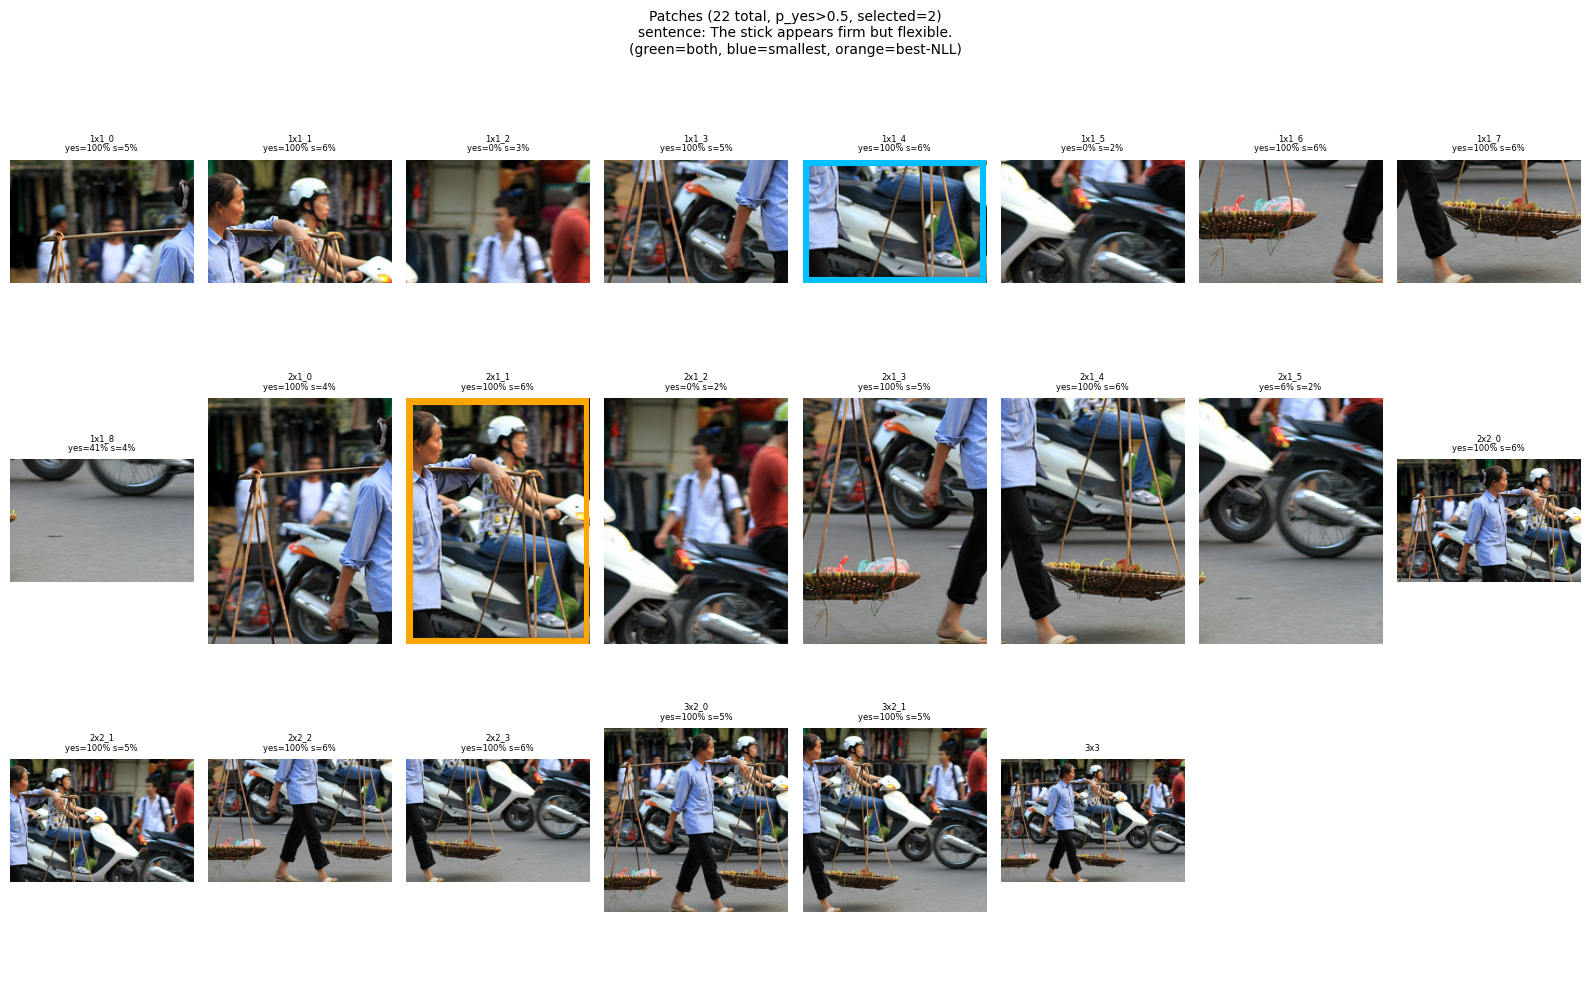

[VQA] Q: Does the image show bamboo is a type of wood that is firm and flexible?
[Passed p_yes>0.5]: 13 patches
[Route1 - Smallest unit (1) → best NLL]: ['1x1_0']
[Route2 - Best NLL]: ['2x1_1']
[Selected]: 2 patches


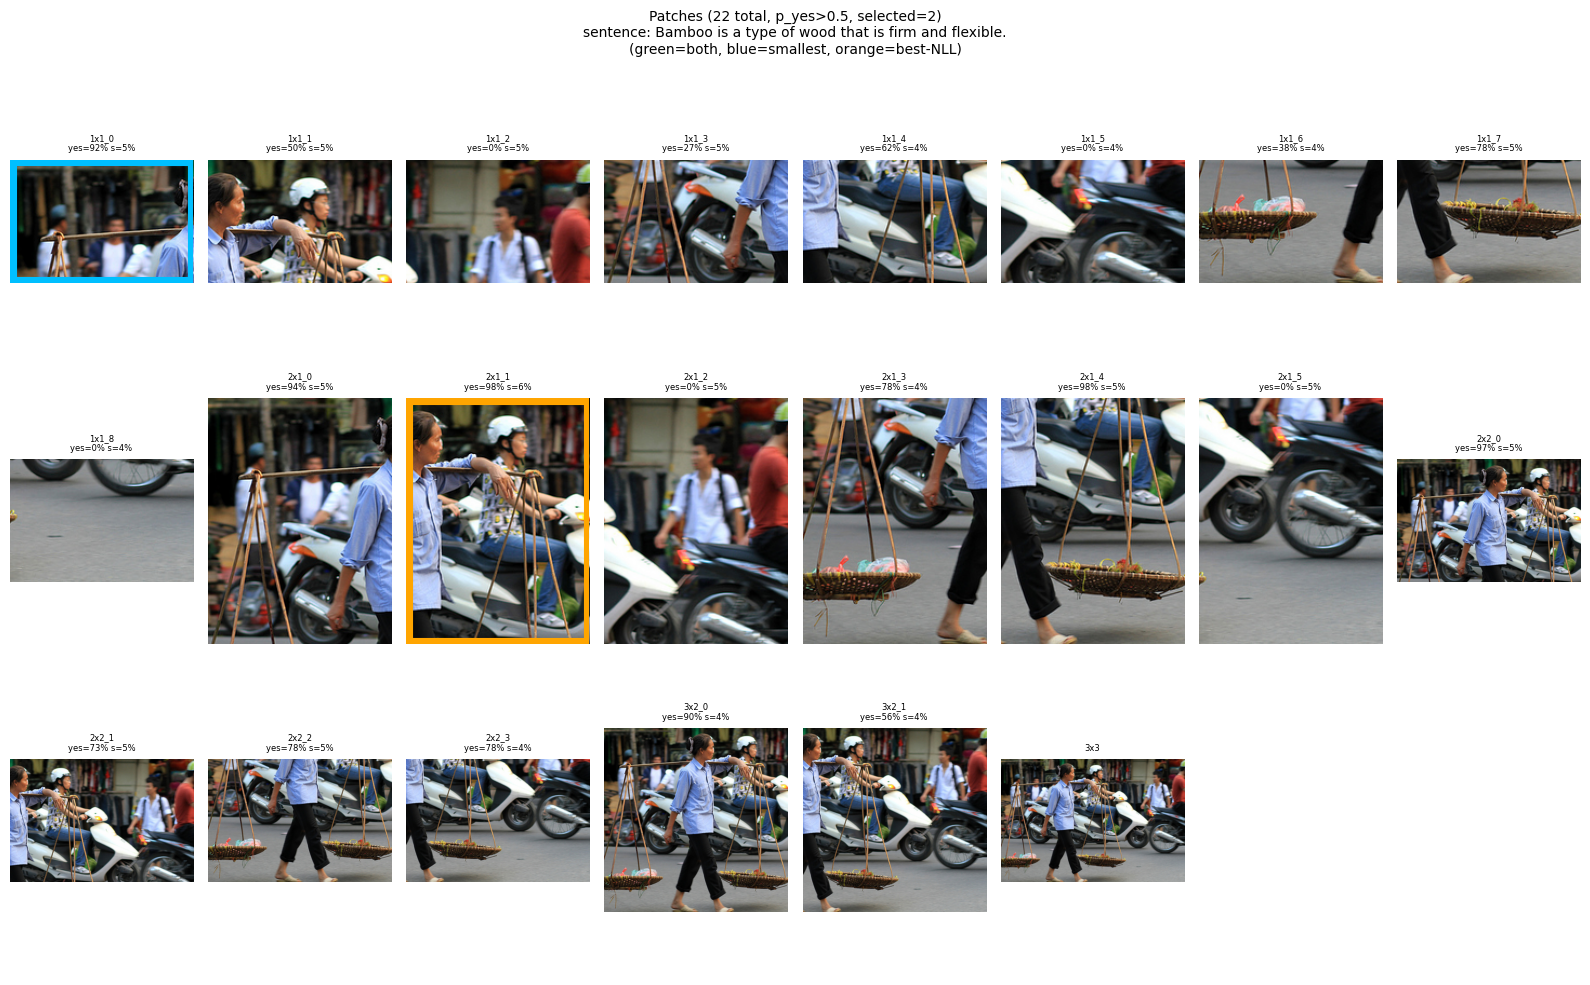

[VQA] Q: Does the image show bamboo grows commonly in asian regions?
[Passed p_yes>0.5]: 13 patches
[Route1 - Smallest unit (1) → best NLL]: ['1x1_1']
[Route2 - Best NLL]: ['1x1_1']
[Selected]: 1 patches


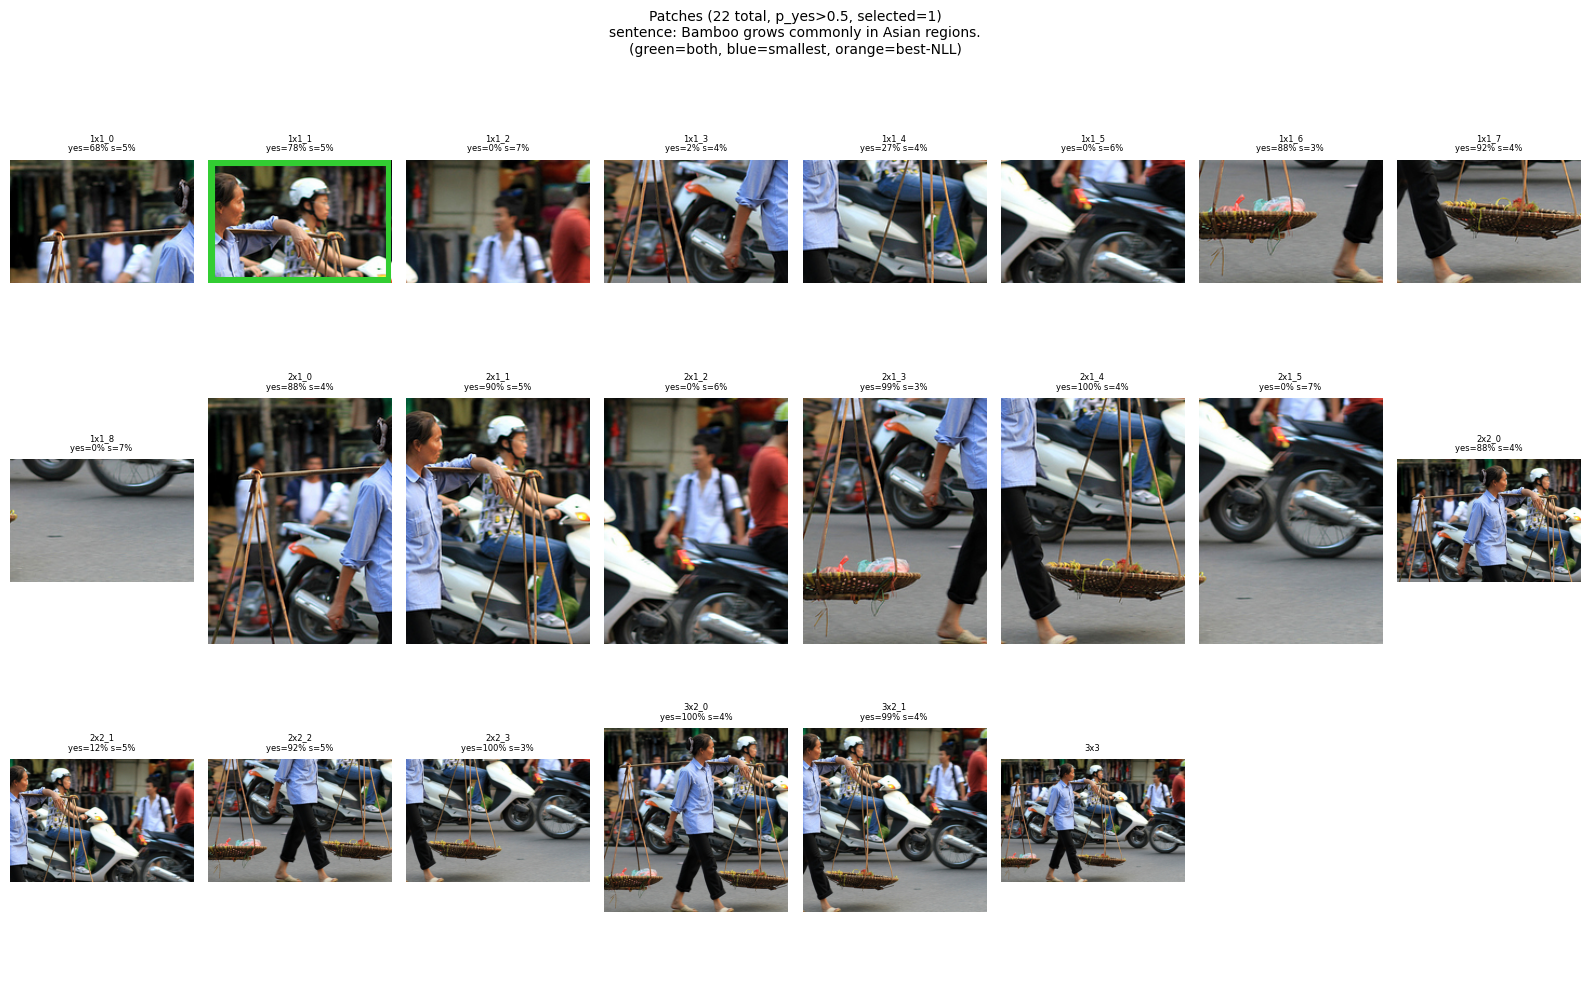

In [4]:
# Pick a sample
ex = edit_ds.data[example_idx]
print(f"Question: {ex['question']}")
print(f"Answer: {ex.get('answer', ex.get('target', ''))}")
print(f"COT: {ex.get('cot', ex.get('rationale', ''))[:200]}...")

# Get first sentence (s1)
import re
cot = ex.get('cot') or ex.get('rationale') or ''
sents = [s.strip() for s in re.split(r"(?<=[.!?])\s+", cot.strip()) if s.strip()]
s1 = sents[0] if sents else ""
print(f"\ns1: {s1}")

# Visualize augmentation (mosaic background + transforms)
editor.augmenter.visualize(ex['image'], text=s1, use_mosaic=True)

# Visualize patches (highlights top-k selected by s1 likelihood)
for s in sents:
    editor.visualize_patches(ex['image'], sentence=s)


## Step 5: Add Edits to Codebook

In [5]:
# Add edits to codebook
editor.edit(config, edit_ds=edit_ds)

# View stats
stats = editor.get_stats()
print("\nCodebook Stats:")
for k, v in stats.items():
    print(f"  {k}: {v}")


[IKE_CHAIN] mode=dual_sbert, pool=mean, pair_rationale_w=both, merge=True, aug_patch=False, aug_orig=False
[IKE_CHAIN] edit 1/10...[Keys] +12 added, 0 merged (from 12 candidates)
[IKE_CHAIN] edit 2/10...[Keys] +10 added, 0 merged (from 10 candidates)
[IKE_CHAIN] edit 3/10...[Keys] +8 added, 0 merged (from 8 candidates)
[IKE_CHAIN] edit 4/10...[Keys] +4 added, 4 merged (from 8 candidates)
[IKE_CHAIN] edit 5/10...[Keys] +7 added, 0 merged (from 7 candidates)
[IKE_CHAIN] edit 6/10...[Keys] +5 added, 6 merged (from 11 candidates)
[IKE_CHAIN] edit 7/10...[Keys] +5 added, 8 merged (from 13 candidates)
[IKE_CHAIN] edit 8/10...[Keys] +4 added, 3 merged (from 7 candidates)
[IKE_CHAIN] edit 9/10...[Keys] +4 added, 3 merged (from 7 candidates)
[IKE_CHAIN] edit 10/10...[Keys] +4 added, 3 merged (from 7 candidates)
[IKE_CHAIN] +10 edits (p_yes>0.5, merge=True, area=0.9), 0->63 keys, 0.2 MB

Codebook Stats:
  num_keys: 63
  num_orig_keys: 43
  num_patch_keys: 20
  num_merged_keys: 19
  num_question_

## Step 6: Visualize Codebook Network


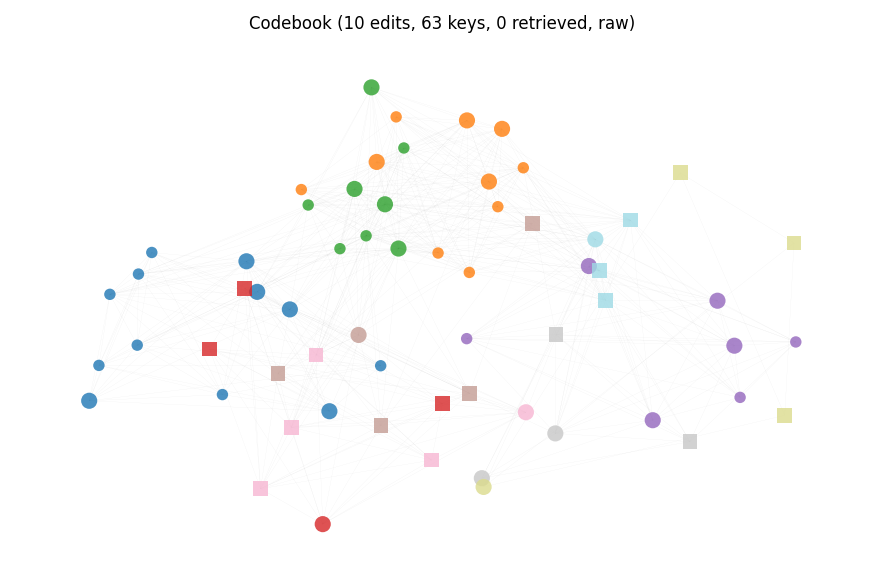

[Hubness] computed sigma for 63 keys (k=30, median=107.03)
[Reject] threshold=1.04 (p50 of 1953 pairs, hubness=True)
[Hubness correction] enabled, scaling distances by σ_k


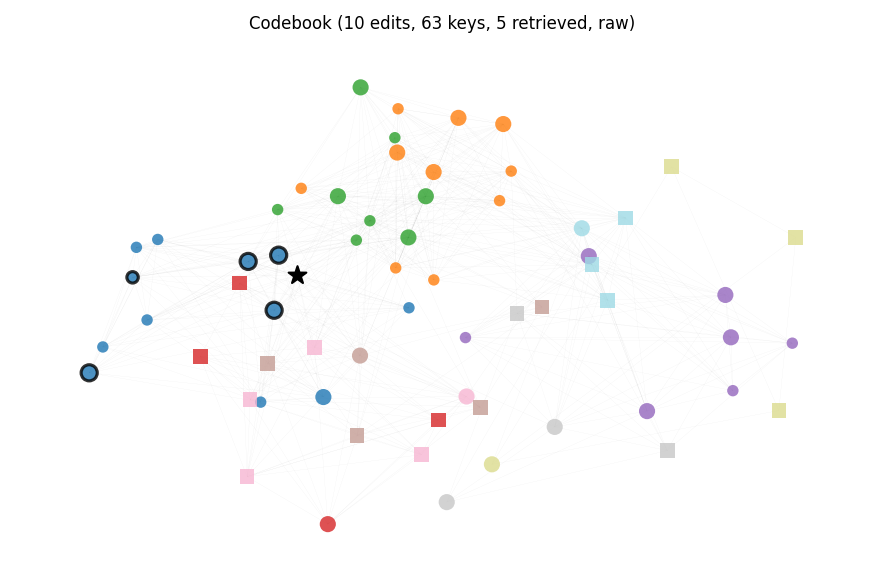

In [6]:
# Plot codebook network (color by edit, size by original vs patch)
editor.plot_codebook()

# Plot with a query point
test_ex = edit_ds.data[example_idx]
editor.plot_codebook(query_img=test_ex['image'], query_text=test_ex['question'])


## Step 7: Test Retrieval


In [7]:
# Test retrieval on training sample (should retrieve)
ex = edit_ds.data[example_idx]
facts = editor._retrieve(ex['image'], ex['question'])
print(f"Query: {ex['question']}")
print(f"Retrieved {len(facts)} facts:")
for i, f in enumerate(facts):
    print(f"  [{i}] {f[:100]}...")


Query: What material is used to make the stick on the woman's shoulder?
Retrieved 4 facts:
  [0] The stick appears firm but flexible....
  [1] Bamboo is a type of wood that is firm and flexible....
  [2] The answer to 'What material is used to make the stick on the woman's shoulder?' is bamboo....
  [3] The image shows a woman with a stick on her shoulder....


## Step 8: Generate with Retrieved Context


In [8]:
# Apply to dataset (prepends retrieved facts to prompts)
editor.apply_to_dataset(edit_ds)

# Check augmented prompt
ex = edit_ds.data[example_idx]
print(f"Original prompt: {ex.get('prompt_orig', 'N/A')}")
print(f"Human rationale: {ex.get('rationale', 'N/A')}")
print(f"proxy Human COT: {ex.get('cot', 'N/A')}")
print(f"Augmented prompt: {ex['prompt']}")

# Generate answer
answer = vlm.generate([ex['image']], [ex['prompt']], max_new_tokens=64)
print(f"\nGenerated: {answer[0]}")
print(f"Gold: {ex.get('gold', {}).get('label', '')}")


[IKE_CHAIN] applied facts to 10/10 examples
Original prompt: What material is used to make the stick on the woman's shoulder?
Human rationale: It is a firm but flexible asian wood. it grows commonly where she lives.
proxy Human COT: The image shows a woman with a stick on her shoulder. The stick appears firm but flexible. Bamboo is a type of wood that is firm and flexible. Bamboo grows commonly in Asian regions.
Augmented prompt: The stick appears firm but flexible. Bamboo is a type of wood that is firm and flexible. The answer to 'What material is used to make the stick on the woman's shoulder?' is bamboo. The image shows a woman with a stick on her shoulder. What material is used to make the stick on the woman's shoulder?

Generated: Based on the visual evidence and the provided context- The stick is part of a traditional shoulder pole (or yoke) used to carry heavy loads in many parts of Asia.- The stick is long, slender, and appears to be made of a natural, light-colored material.- 

## Step 9: Test with Generality Evaluation Samples


In [9]:
# Load generality evaluation data for ALL samples (run once)
from revlm.metrics.utils.t_gen import get_t_gen_input
from revlm.metrics.utils.i_gen import get_i_gen_input
from revlm.metrics.utils.r_gen import get_r_gen_input
from PIL import Image

dataset_name = config.experiment.dataset_name

related_texts = get_t_gen_input(dataset_name, edit_ds)
related_images = get_i_gen_input(dataset_name, edit_ds)
related_r_gen_df = get_r_gen_input(dataset_name, edit_ds)

print(f"Loaded generality data for {len(edit_ds.data)} samples")
print(f"Text gen UIDs: {len(related_texts)}, Image gen UIDs: {len(related_images)}, Rationale gen rows: {len(related_r_gen_df)}")


[r_gen] Loaded: 132119 rows, 18181 uids
[r_gen] After bad_sids filter: 118652 rows, 18147 uids (removed 13467)
[r_gen] After edit_ds filter: 66 rows, 10 uids
Loaded generality data for 10 samples
Text gen UIDs: 10, Image gen UIDs: 10, Rationale gen rows: 66


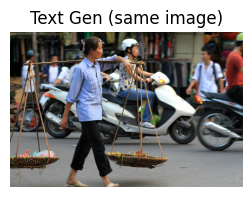

[example_idx=0] Original Q: What material is used to make the stick on the woman's shoulder?
Paraphrased Q: What type of material is the stick on the woman's shoulder made from?
Retrieved 4 facts:
  [0] The stick appears firm but flexible....
  [1] Bamboo is a type of wood that is firm and flexible....
  [2] The answer to 'What material is used to make the stick on the woman's shoulder?' is bamboo....
  [3] The image shows a woman with a stick on her shoulder....


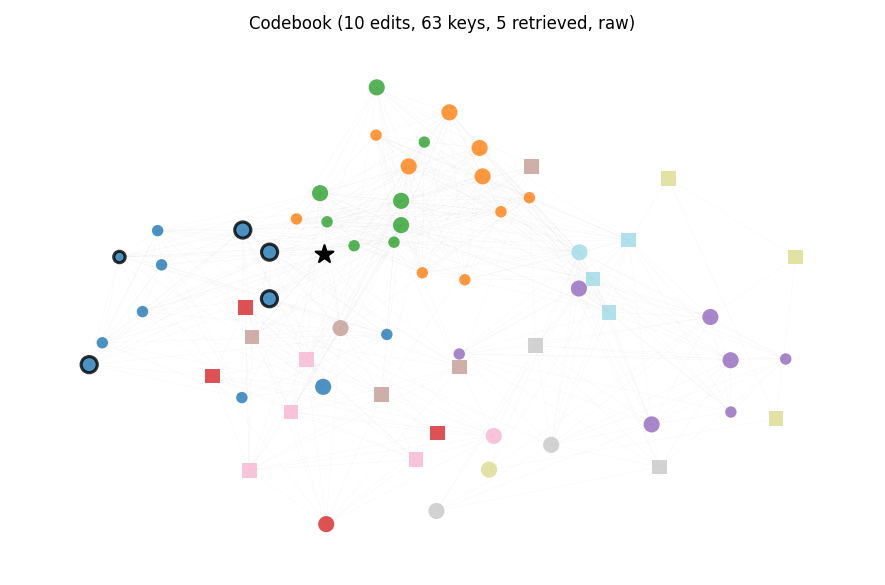

In [10]:
# =============================================

# Text Generality: same image, paraphrased question
import matplotlib.pyplot as plt
ex = edit_ds.data[example_idx]
uid = str(ex["uid"])
if uid in related_texts:
    t_gen_q = related_texts[uid][0]
    img = ex["image"] if isinstance(ex["image"], Image.Image) else Image.open(ex["image"]).convert("RGB")
    plt.figure(figsize=(3,3)); plt.imshow(img); plt.axis('off'); plt.title("Text Gen (same image)"); plt.show()
    print(f"[example_idx={example_idx}] Original Q: {ex['question']}")
    print(f"Paraphrased Q: {t_gen_q}")
    facts = editor._retrieve(img, t_gen_q)
    print(f"Retrieved {len(facts)} facts:")
    for i, f in enumerate(facts):
        print(f"  [{i}] {f[:100]}...")
    editor.plot_codebook(query_img=img, query_text=t_gen_q)
else:
    print(f"No text generality data for uid={uid}")


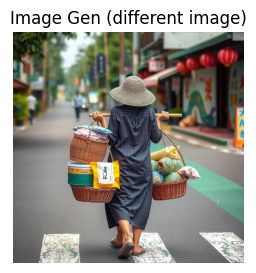

Question: What material is used to make the stick on the woman's shoulder?
Image: data/related_image/aokvqa/train_44065/flux_0.png
Retrieved 3 facts:
  [0] The stick appears firm but flexible....
  [1] The answer to 'What material is used to make the stick on the woman's shoulder?' is bamboo....
  [2] The image shows a woman with a stick on her shoulder....


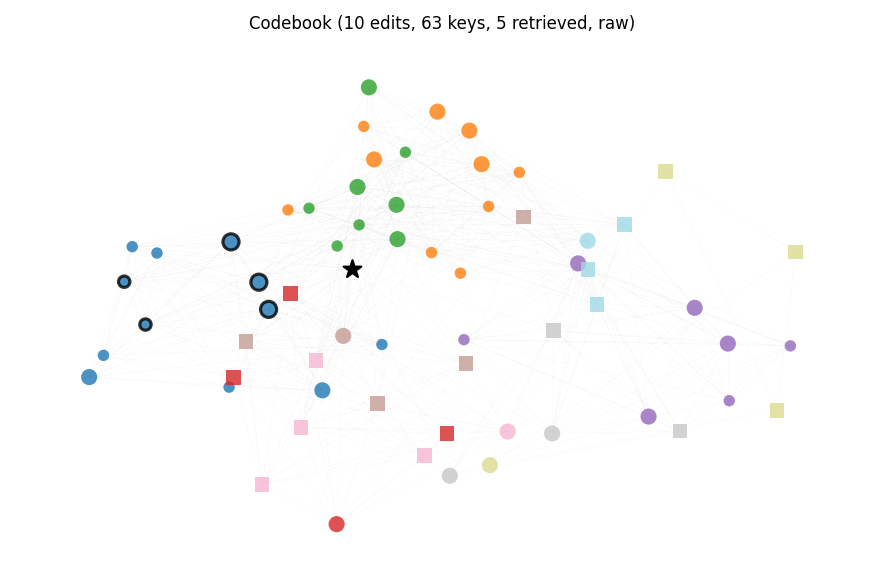

In [11]:
# Image Generality: same question, different image
ex = edit_ds.data[example_idx]
uid = str(ex["uid"])
if uid in related_images:
    i_gen_img = Image.open(related_images[uid][0]).convert("RGB")
    plt.figure(figsize=(3,3)); plt.imshow(i_gen_img); plt.axis('off'); plt.title("Image Gen (different image)"); plt.show()
    print(f"Question: {ex['question']}")
    print(f"Image: {related_images[uid][0]}")
    facts = editor._retrieve(i_gen_img, ex["question"])
    print(f"Retrieved {len(facts)} facts:")
    for i, f in enumerate(facts):
        print(f"  [{i}] {f[:100]}...")
    editor.plot_codebook(query_img=i_gen_img, query_text=ex["question"])
else:
    print(f"No image generality data for uid={uid}")


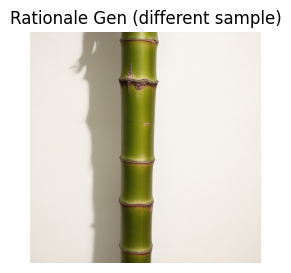

Question: What type of wood is firm and flexible?
Image: data/r_gen/image/aokvqa/9780_6.png
Retrieved 3 facts:
  [0] The answer to 'From all food items present what is the color of food that presents the most moisture...
  [1] Bamboo is a type of wood that is firm and flexible....
  [2] Sweet potatoes are known to have a high moisture content....


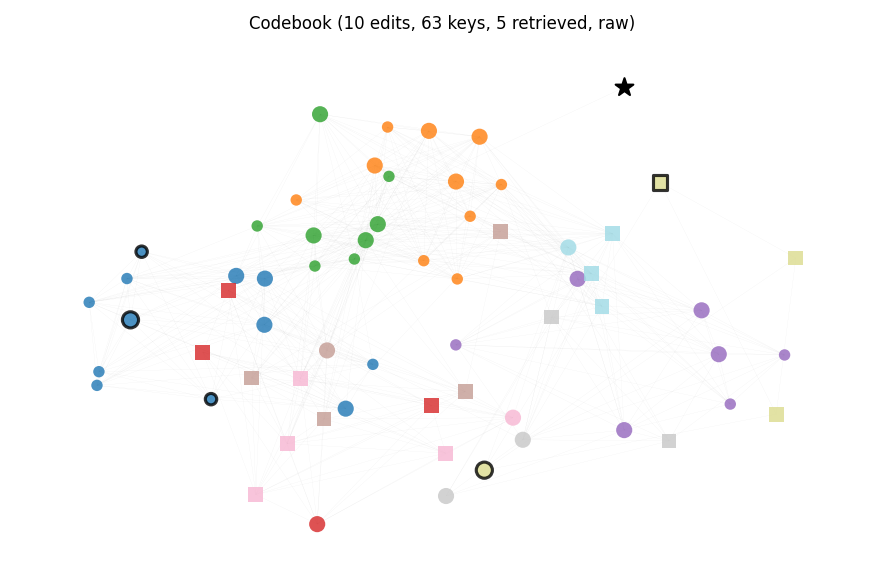

In [12]:

# Rationale Generality: different sample from same edit
ex = edit_ds.data[example_idx]
uid = str(ex["uid"])
r_gen_for_uid = related_r_gen_df[related_r_gen_df["uid"] == uid]
if len(r_gen_for_uid) > 0:
    row = r_gen_for_uid.iloc[5]
    # row['question'] = "Does the image show a spindle and a cordless phone?"
    r_gen_img = Image.open(row["image_path"]).convert("RGB")
    plt.figure(figsize=(3,3)); plt.imshow(r_gen_img); plt.axis('off'); plt.title("Rationale Gen (different sample)"); plt.show()
    print(f"Question: {row['question']}")
    print(f"Image: {row['image_path']}")
    facts = editor._retrieve(r_gen_img, row["question"])
    print(f"Retrieved {len(facts)} facts:")
    for i, f in enumerate(facts):
        print(f"  [{i}] {f[:100]}...")
    editor.plot_codebook(query_img=r_gen_img, query_text=row["question"])
else:
    print(f"No rationale generality data for uid={uid}")
